In [1]:
import os
os.chdir('/home/yajatyadav/multitask_reinforcement_learning/multitask_RL')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['MUJOCO_GL'] = 'egl'
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags
if 'CUDA_VISIBLE_DEVICES' in os.environ:
    os.environ['EGL_DEVICE_ID'] = os.environ['CUDA_VISIBLE_DEVICES']
    os.environ['MUJOCO_EGL_DEVICE_ID'] = os.environ['CUDA_VISIBLE_DEVICES']

import copy
from typing import Any

import flax
import flax.linen as nn
import jax
import jax.numpy as jnp
import ml_collections
import optax
import tqdm
import numpy as np
import math
import random

from utils.encoders import encoder_modules
from utils.flax_utils import ModuleDict, TrainState, nonpytree_field, restore_agent_with_file
import pickle
from utils.networks import MLP
from typing import Sequence


from envs.libero_utils import get_dataset as get_libero_dataset, make_env as make_libero_env
from evaluation_libero import evaluate
from utils.log_utils import get_wandb_video

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /home/yajatyadav/multitask_reinforcement_learning/multitask_RL/.venv/lib/python3.11/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [2]:
class TransClassifier_BERT(nn.Module):
    vision_encoder: nn.Module = None    
    layer_norm: bool = True
    p_drop_state: float = 0.5
    embed_dim: int = 128

    def setup(self):
        # Action encoder: action_dim -> 128
        self.action_encoder = MLP((self.embed_dim, self.embed_dim), activate_final=True, layer_norm=self.layer_norm)
        
        # Language encoder: 768 (BERT) -> 128
        self.lang_encoder = MLP((self.embed_dim, self.embed_dim), activate_final=True, layer_norm=self.layer_norm)
        
        # Final classifier: 384 (128*3) -> 128 -> 128 -> 1
        self.classifier = MLP((self.embed_dim, self.embed_dim, 1), activate_final=False, layer_norm=self.layer_norm)
    
    def __call__(self, observations, actions, language_embedding, train=True, rng=None):
        """
        Args:
            observations: (batch, obs_dim)
            actions: (batch, action_dim)
            language_embedding: (batch, 768) - BERT embedding
            train: whether to apply dropout
            rng: random key for dropout
            
        Returns:
            logits: (batch, 1) - scalar logit for P(lang | obs, action)
        """
        assert actions is not None, "Actions must be provided to the classifier"
        assert self.vision_encoder is not None, "Encoder must be provided to the classifier"
        
        # Encode observations -> (batch, 128)
        obs_encoded = self.vision_encoder(observations)

        # Dropout on obs encoding
        if rng is None:
            rng = jax.random.PRNGKey(0)
        mask = jax.random.bernoulli(rng, 1 - self.p_drop_state, shape=(obs_encoded.shape[0], 1))
        obs_encoded = jax.lax.cond(
            train,
            lambda x: mask * x,
            lambda x: x,
            obs_encoded
        )
        
        # Encode actions -> (batch, 128)
        action_encoded = self.action_encoder(actions)
        
        # Encode language -> (batch, 128)
        lang_encoded = self.lang_encoder(language_embedding)
        
        # Concatenate all three -> (batch, 384)
        inputs = jnp.concatenate([obs_encoded, action_encoded, lang_encoded], axis=-1)
        
        # Final classification -> (batch, 1)
        return self.classifier(inputs)

In [3]:
train_percent, val_percent, test_percent = 0.9, 0.05, 0.05
tot_num_demos_per_task = 50
train_num_demos_per_task = int(train_percent * tot_num_demos_per_task)
val_num_demos_per_task = int(val_percent * tot_num_demos_per_task)
test_num_demos_per_task = tot_num_demos_per_task - train_num_demos_per_task - val_num_demos_per_task




shuffled_demo_nums = np.random.permutation(tot_num_demos_per_task)
train_demo_nums_to_use = list(shuffled_demo_nums[:train_num_demos_per_task])
val_demo_nums_to_use = list(shuffled_demo_nums[train_num_demos_per_task:train_num_demos_per_task + val_num_demos_per_task])
test_demo_nums_to_use = list(shuffled_demo_nums[train_num_demos_per_task + val_num_demos_per_task:])

keys_to_load = ['agentview_rgb', 'eye_in_hand_rgb', 'language']
env_names = 'libero_90-living_room_scene1-pick_up_the_alphabet_soup_and_put_it_in_the_basket|libero_90-living_room_scene1-pick_up_the_ketchup_and_put_it_in_the_basket|libero_goal-open_the_middle_drawer_of_the_cabinet|libero_goal-turn_on_the_stove|libero_spatial-pick_up_the_black_bowl_on_the_cookie_box_and_place_it_on_the_plate|libero_spatial-pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate'
env_names = env_names.split('|')


# EDIT THIS!!!
env_name = env_names[4] + '|' + env_names[5]


task_name = ''
augmentation_type = 'none'
augmentation_reward = False
language_embedder = 'bert'

train_dataset = get_libero_dataset(None, env_name, task_name, language_embedder, augmentation_type, augmentation_reward, keys_to_load, demo_nums_to_use_per_task=train_demo_nums_to_use, augmentation_dict=None)
print(f"main.py:Made env and datasets.Train dataset size: {train_dataset.size}", flush=True)
val_dataset = get_libero_dataset(None, env_name, task_name, language_embedder, augmentation_type, augmentation_reward, keys_to_load, demo_nums_to_use_per_task=val_demo_nums_to_use, augmentation_dict=None)
print(f"main.py:Made env and datasets.Val dataset size: {val_dataset.size}", flush=True)
test_dataset = get_libero_dataset(None, env_name, task_name, language_embedder, augmentation_type, augmentation_reward, keys_to_load, demo_nums_to_use_per_task=test_demo_nums_to_use, augmentation_dict=None)
print(f"main.py:Made env and datasets.Test dataset size: {test_dataset.size}", flush=True)

🤪🤪🤪 augmentation_reward: False
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
all env names: defaultdict(<class 'list'>, {'libero_spatial': ['libero_spatial-pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate', 'libero_spatial-pick_up_the_black_bowl_on_the_cookie_box_and_place_it_on_the_plate']})
🤪🤪🤪 all_libero_env_names: defaultdict(<class 'list'>, {'libero_spatial': ['libero_spatial-pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate', 'libero_spatial-pick_up_the_black_bowl_on_the_cookie_box_and_place_it_on_the_plate']})
😎😎😎 ONLY using [np.int64(28), np.int64(11), np.int64(10), np.int64(41), np.int64(2), np.int64(27), np.int64(38), np.int64(31), np.int64(22), np.int64(4), np.int64(33), np.int64(35), np.int64(26), np.int64(34), np.int64(18), np.int64(7), np.int64(14), np.int64(45), np.int64(48), np.int64(29), np.int64(15), np.int64(30), np.int64(32

In [4]:
# all hparams
batch_size = 256
horizon_length = 5
discount = 0.99
encoder = 'image_only_tiny'
embed_dim = encoder_modules[encoder]().mlp_hidden_dims[-1]
layer_norm = True
lr  = 3e-4
p_drop_state = 0.5

example_batch = train_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
ex_observations = example_batch['observations']
ex_actions = example_batch['actions']
ex_lang_embedding = ex_observations.pop('language')
full_actions = jnp.reshape(ex_actions, (ex_actions.shape[0], -1))
lang_embedding_dim = ex_lang_embedding.shape[-1]
print(f"lang_embedding_dim: {lang_embedding_dim}, action_dim: {full_actions.shape[-1]}")

rng = jax.random.PRNGKey(SEED)
val_rng = jax.random.PRNGKey(SEED + 100)
rng, init_rng = jax.random.split(rng, 2)
classifier_def = TransClassifier_BERT(
    vision_encoder=encoder_modules[encoder](),
    embed_dim=embed_dim,
    layer_norm=layer_norm,
    p_drop_state=p_drop_state,
)

network_info = dict(
    classifier=(classifier_def, (ex_observations, full_actions, ex_lang_embedding, True, init_rng)),
)
networks = {k: v[0] for k, v in network_info.items()}
network_args = {k: v[1] for k, v in network_info.items()}
network_def = ModuleDict(networks)
network_tx = optax.adam(learning_rate=lr)
network_params = network_def.init(init_rng, **network_args)['params']
network = TrainState.create(network_def, network_params, tx=network_tx)

from utils.log_utils import build_network_tree
build_network_tree(network.params)

lang_embedding_dim: 768, action_dim: 35


Network Parameters
└── modules_classifier/
    ├── vision_encoder/
    │   └── ImpalaEncoder_0/
    │       ├── stack_blocks_0/
    │       │   ├── Conv_0/
    │       │   │   ├── kernel: (3, 3, 6, 4) float32 (216 params)
    │       │   │   └── bias: (4,) float32 (4 params)
    │       │   ├── Conv_1/
    │       │   │   ├── kernel: (3, 3, 4, 4) float32 (144 params)
    │       │   │   └── bias: (4,) float32 (4 params)
    │       │   └── Conv_2/
    │       │       ├── kernel: (3, 3, 4, 4) float32 (144 params)
    │       │       └── bias: (4,) float32 (4 params)
    │       ├── stack_blocks_1/
    │       │   ├── Conv_0/
    │       │   │   ├── kernel: (3, 3, 4, 4) float32 (144 params)
    │       │   │   └── bias: (4,) float32 (4 params)
    │       │   ├── Conv_1/
    │       │   │   ├── kernel: (3, 3, 4, 4) float32 (144 params)
    │       │   │   └── bias: (4,) float32 (4 params)
    │       │   └── Conv_2/
    │       │       ├── kernel: (3, 3, 4, 4) float32 (144 params)
    │       │       └── bias: (4,) float32 (4 params)
    │       └── MLP_0/
    │           └── Dense_0/
    │               ├── kernel: (4096, 128) float32 (524,288 params)
    │               └── bias: (128,) float32 (128 params)
    ├── action_encoder/
    │   ├── Dense_0/
    │   │   ├── kernel: (35, 128) float32 (4,480 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   ├── LayerNorm_0/
    │   │   ├── scale: (128,) float32 (128 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   ├── Dense_1/
    │   │   ├── kernel: (128, 128) float32 (16,384 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   └── LayerNorm_1/
    │       ├── scale: (128,) float32 (128 params)
    │       └── bias: (128,) float32 (128 params)
    ├── lang_encoder/
    │   ├── Dense_0/
    │   │   ├── kernel: (768, 128) float32 (98,304 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   ├── LayerNorm_0/
    │   │   ├── scale: (128,) float32 (128 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   ├── Dense_1/
    │   │   ├── kernel: (128, 128) float32 (16,384 params)
    │   │   └── bias: (128,) float32 (128 params)
    │   └── LayerNorm_1/
    │       ├── scale: (128,) float32 (128 params)
    │       └── bias: (128,) float32 (128 params)
    └── classifier/
        ├── Dense_0/
        │   ├── kernel: (384, 128) float32 (49,152 params)
        │   └── bias: (128,) float32 (128 params)
        ├── LayerNorm_0/
        │   ├── scale: (128,) float32 (128 params)
        │   └── bias: (128,) float32 (128 params)
        ├── Dense_1/
        │   ├── kernel: (128, 128) float32 (16,384 params)
        │   └── bias: (128,) float32 (128 params)
        ├── LayerNorm_1/
        │   ├── scale: (128,) float32 (128 params)
        │   └── bias: (128,) float32 (128 params)
        └── Dense_2/
            ├── kernel: (128, 1) float32 (128 params)
            └── bias: (1,) float32 (1 params)

In [5]:
BERT_HIDDEN_DIM = 768
all_possible_lang_embeddings = set()
for i in range(100):
    batch = train_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
    for lang_embedding in batch['observations']['language']:
        lang_embedding = tuple(lang_embedding)
        all_possible_lang_embeddings.add(lang_embedding)
all_possible_lang_embeddings = [np.array(lang_embedding) for lang_embedding in all_possible_lang_embeddings]

other_lang_embeddings_map = {tuple(lang_embedding): [] for lang_embedding in all_possible_lang_embeddings}
for lang_embedding in other_lang_embeddings_map:
    for other_lang_embedding in all_possible_lang_embeddings:
        if np.any(lang_embedding != other_lang_embedding):
            other_lang_embeddings_map[lang_embedding].append(other_lang_embedding)

NUM_TASKS = 2
assert [len(x) == NUM_TASKS - 1 for x in other_lang_embeddings_map.values()]

In [6]:
train_losses, val_losses = [], []
val_accuracies = []
grad_max, grad_min, grad_norm = [], [], []

def sample_negative_lang(batch, rng):
    """Sample negative embeddings - call BEFORE JIT-compiled functions."""
    lang_embedding = batch['observations']['language']
    batch_size = lang_embedding.shape[0]
    
    neg_embeddings = []
    for i in range(batch_size):
        key = tuple(np.array(lang_embedding[i]))
        candidates = other_lang_embeddings_map[key]
        idx = int(jax.random.randint(rng, (), 0, len(candidates)))
        rng, _ = jax.random.split(rng)
        neg_embeddings.append(candidates[idx])
    return jnp.array(neg_embeddings), rng

def get_loss_fn(batch, neg_lang, train, rng):    
    def loss_fn(grad_params):
        masked_actions = batch['actions'] * batch['masks'][..., None]
        batch_actions = jnp.reshape(masked_actions, (masked_actions.shape[0], -1))
        pos_lang = batch['observations'].pop('language')  # (batch, 768)
        
        pos_rng, neg_rng = jax.random.split(rng)
        # Positive examples: correct (obs, action, lang) triplets
        pos_logits = network.select('classifier')(
            batch['observations'], batch_actions, pos_lang,
            params=grad_params, train=train, rng=pos_rng
        )  # (batch, 1)
        
        # Negative examples: use pre-sampled embeddings
        neg_logits = network.select('classifier')(
            batch['observations'], batch_actions, neg_lang,
            params=grad_params, train=train, rng=neg_rng
        )  # (batch, 1)
        
        # Binary cross-entropy: positives -> 1, negatives -> 0
        pos_loss = optax.sigmoid_binary_cross_entropy(pos_logits, jnp.ones_like(pos_logits))
        neg_loss = optax.sigmoid_binary_cross_entropy(neg_logits, jnp.zeros_like(neg_logits))
        classifier_loss = jnp.mean(pos_loss) + jnp.mean(neg_loss)
        
        return classifier_loss, {
            'classifier_loss': classifier_loss,
            'pos_loss': jnp.mean(pos_loss),
            'neg_loss': jnp.mean(neg_loss),
        }
    return loss_fn

def accuracy(network, batch, rng):
    neg_lang, rng = sample_negative_lang(batch, rng)
    
    pos_lang = batch['observations'].pop('language')
    batch_masked_actions = batch['actions'] * batch['masks'][..., None]
    batch_actions = jnp.reshape(batch_masked_actions, (batch_masked_actions.shape[0], -1))
    
    # Positive examples
    pos_logits = network.select('classifier')(
        batch['observations'], batch_actions, pos_lang,
        train=False, params=network.params
    )
    
    # Negative examples
    neg_logits = network.select('classifier')(
        batch['observations'], batch_actions, neg_lang,
        train=False, params=network.params
    )
    
    # Correct if model assigns higher score to true lang than sampled neg lang
    num_correct = jnp.sum(pos_logits > neg_logits)
    num_total = pos_logits.shape[0]
    
    return num_correct, num_total
    

@jax.jit
def update(network, batch, neg_lang, rng):
    new_rng, rng = jax.random.split(rng)
    loss_fn = get_loss_fn(batch, neg_lang, True, rng)
    new_network, info = network.apply_loss_fn(loss_fn=loss_fn)
    network, rng = new_network, new_rng
    return network, rng, info

print(train_dataset.size)
NUM_EPOCHS = 2
VAL_INTERVAL = 10
num_train_steps = NUM_EPOCHS * math.ceil(train_dataset.size / batch_size)
for step in tqdm.tqdm(range(1, num_train_steps+1), total=num_train_steps, desc="Training"):
    batch = train_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
    neg_lang, rng = sample_negative_lang(batch, rng)
    network, rng, info = update(network, batch, neg_lang, rng)
    train_losses.append((step, info['classifier_loss'], info['pos_loss'], info['neg_loss']))
    grad_max.append((step, info['grad/max']))
    grad_min.append((step, info['grad/min']))
    grad_norm.append((step, info['grad/norm']))
    if (VAL_INTERVAL > 0 and (step == 1 or step % VAL_INTERVAL == 0)):
        val_batch = val_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
        val_neg_lang, val_rng = sample_negative_lang(val_batch, val_rng)
        val_batch_copy = copy.deepcopy(val_batch)
        val_rng, val_loss_rng, val_acc_rng = jax.random.split(val_rng, 3)
        loss_fn = get_loss_fn(val_batch, val_neg_lang, False, val_loss_rng)
        loss, info = loss_fn(network.params)
        num_correct, num_total = accuracy(network, val_batch_copy, val_acc_rng)
        val_losses.append((step, info['classifier_loss'], info['pos_loss'], info['neg_loss']))
        val_accuracies.append((step, num_correct / num_total))

11294


Training: 100%|██████████| 90/90 [00:33<00:00,  2.72it/s]


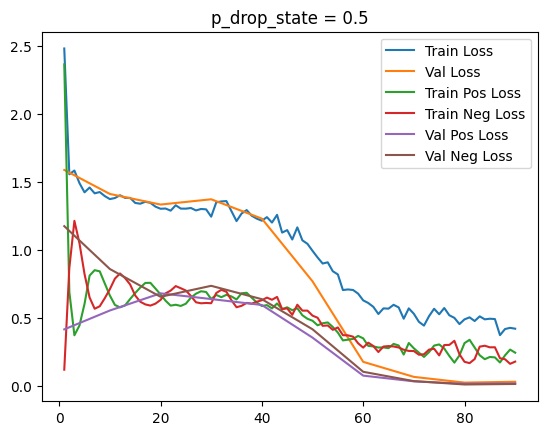

Last train loss: 0.41901296377182007
Last val loss: 0.028220931068062782


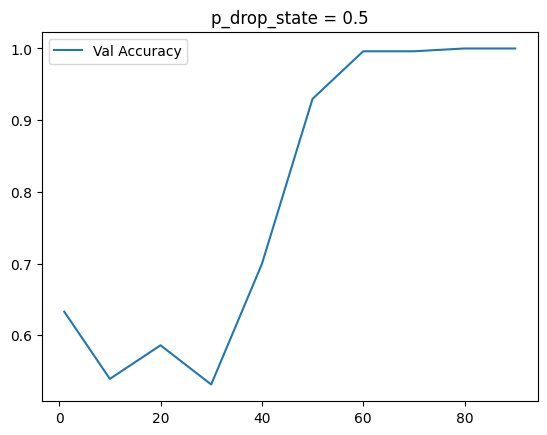

Last val accuracy: 1.0


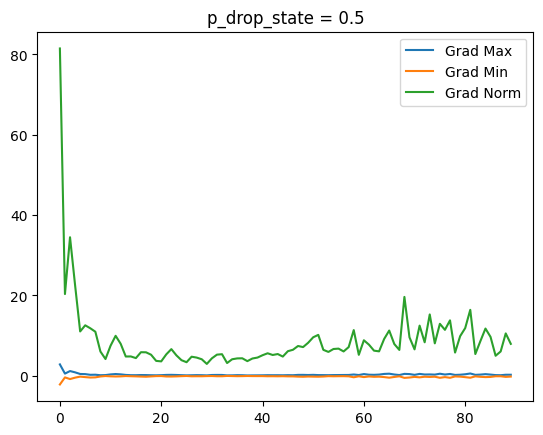

In [7]:
# visualize train and val losses lists on the same plot, scale val by VAL_INTERVAL
import matplotlib.pyplot as plt


train_x_vals = [x[0] for x in train_losses]
train_y_vals = [x[1] for x in train_losses]
train_pos_loss_vals = [x[2] for x in train_losses]
train_neg_loss_vals = [x[3] for x in train_losses]
val_x_vals = [x[0] for x in val_losses]
val_y_vals = [x[1] for x in val_losses]
val_pos_loss_vals = [x[2] for x in val_losses]
val_neg_loss_vals = [x[3] for x in val_losses]
plt.plot(train_x_vals, train_y_vals, label='Train Loss')
plt.plot(val_x_vals, val_y_vals, label='Val Loss')
plt.plot(train_x_vals, train_pos_loss_vals, label='Train Pos Loss')
plt.plot(train_x_vals, train_neg_loss_vals, label='Train Neg Loss')
plt.plot(val_x_vals, val_pos_loss_vals, label='Val Pos Loss')
plt.plot(val_x_vals, val_neg_loss_vals, label='Val Neg Loss')

plt.title(f"p_drop_state = {p_drop_state}")
plt.legend()
plt.show()
print(f"Last train loss: {train_y_vals[-1]}")
print(f"Last val loss: {val_y_vals[-1]}")

# plot val_accuracies
plt.plot(val_x_vals, [x[1] for x in val_accuracies], label='Val Accuracy')
plt.title(f"p_drop_state = {p_drop_state}")
plt.legend()
plt.show()
print(f"Last val accuracy: {val_accuracies[-1][1]}")

# also plot grad_max, grad_min, grad_norm
plt.plot([x[1] for x in grad_max], label='Grad Max')
plt.plot([x[1] for x in grad_min], label='Grad Min')
plt.plot([x[1] for x in grad_norm], label='Grad Norm')
plt.title(f"p_drop_state = {p_drop_state}")
plt.legend()
plt.show()

# Testing

In [8]:
# testing time, first by simply calling on test-batches, then visualizing!!
all_test_demo_nums = val_demo_nums_to_use + test_demo_nums_to_use
all_test_dataset = get_libero_dataset(None, env_name, task_name, language_embedder, augmentation_type, augmentation_reward, keys_to_load, demo_nums_to_use_per_task=all_test_demo_nums, augmentation_dict=None)
test_rng = jax.random.PRNGKey(SEED + 200)
num_test_steps = 5 * all_test_dataset.size // batch_size # dataset object is implemented as infinite, but 100 should be good enough w/ a batch size of 256
test_num_correct, test_num_total = 0, 0
for i in tqdm.tqdm(range(num_test_steps), total=num_test_steps, desc="Testing"):
    test_batch = all_test_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
    this_test_rng, test_rng = jax.random.split(test_rng)
    num_correct, num_total = accuracy(network, test_batch, this_test_rng)
    test_num_correct += num_correct
    test_num_total += num_total
avg_test_acc = test_num_correct / test_num_total
print(f"Test accuracy of {p_drop_state}: {avg_test_acc}, {test_num_correct}/{test_num_total}")

# testing time, first by simply calling on test-batches, then visualizing!!
num_test_steps = 50 # dataset is infinite, but 100 should be good enough w/ a batch size of 256
test_num_correct_zero_action, test_num_total_zero_action = 0, 0
for i in tqdm.tqdm(range(num_test_steps), total=num_test_steps, desc="Testing"):
    test_batch = all_test_dataset.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
    # zero out both images before feeding into accuracy()
    # test_batch['observations']['agentview_rgb'] = jnp.zeros_like(test_batch['observations']['agentview_rgb'])
    # test_batch['observations']['eye_in_hand_rgb'] = jnp.zeros_like(test_batch['observations']['eye_in_hand_rgb'])
    # zero out action
    test_batch['actions'] = jnp.zeros_like(test_batch['actions'])    
    this_test_rng, test_rng = jax.random.split(test_rng)
    num_correct, num_total = accuracy(network, test_batch, this_test_rng)
    test_num_correct_zero_action += num_correct
    test_num_total_zero_action += num_total
avg_test_acc_zero_action = test_num_correct_zero_action / test_num_total_zero_action
print(f"Test accuracy with action zeroed out of {p_drop_state}: {avg_test_acc_zero_action}, {test_num_correct_zero_action}/{test_num_total_zero_action}")

🤪🤪🤪 augmentation_reward: False
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
all env names: defaultdict(<class 'list'>, {'libero_spatial': ['libero_spatial-pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate', 'libero_spatial-pick_up_the_black_bowl_on_the_cookie_box_and_place_it_on_the_plate']})
🤪🤪🤪 all_libero_env_names: defaultdict(<class 'list'>, {'libero_spatial': ['libero_spatial-pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate', 'libero_spatial-pick_up_the_black_bowl_on_the_cookie_box_and_place_it_on_the_plate']})
😎😎😎 ONLY using [np.int64(46), np.int64(3), np.int64(0), np.int64(47), np.int64(44)] demos for target_task: pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate
🥳🥳🥳 j=0 Dataset for pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate has 717, and zero_out_rewar

Testing: 100%|██████████| 24/24 [00:08<00:00,  2.86it/s]


Test accuracy of 0.5: 1.0, 6144/6144


Testing: 100%|██████████| 50/50 [00:17<00:00,  2.93it/s]

Test accuracy with action zeroed out of 0.5: 1.0, 12800/12800


In [9]:
test_batch = all_test_dataset.sample_sequence(5, sequence_length=horizon_length, discount=discount)
original_lang_embedding = np.array(test_batch['observations']['language'])
other_embedding, test_rng = sample_negative_lang(test_batch, test_rng)
print(f"shape of original_lang_embedding: {original_lang_embedding.shape}, shape of other_embedding: {other_embedding.shape}")

masked_actions = test_batch['actions'] * test_batch['masks'][..., None]
batch_actions = jnp.reshape(masked_actions, (masked_actions.shape[0], -1))
pos_logits = network.select('classifier')(test_batch['observations'], batch_actions, original_lang_embedding, train=False, params=network.params)
neg_logits = network.select('classifier')(test_batch['observations'], batch_actions, other_embedding, train=False, params=network.params)
print(f"Pos logits: {pos_logits}, Neg logits: {neg_logits}")
print(f"Pos logits shape: {pos_logits.shape}, Neg logits shape: {neg_logits.shape}")

shape of original_lang_embedding: (5, 768), shape of other_embedding: (5, 768)
Pos logits: [[5.447937 ]
 [5.7896876]
 [6.44981  ]
 [3.0353172]
 [4.251994 ]], Neg logits: [[-5.588134 ]
 [-5.6773243]
 [-5.403761 ]
 [-3.6952612]
 [-4.700135 ]]
Pos logits shape: (5, 1), Neg logits shape: (5, 1)


In [10]:
# testing across time!
# combine val and test datasets
all_test_demo_nums = val_demo_nums_to_use + test_demo_nums_to_use
all_test_dataset = get_libero_dataset(None, env_name, task_name, language_embedder, augmentation_type, augmentation_reward, keys_to_load, demo_nums_to_use_per_task=all_test_demo_nums, augmentation_dict=None)
T = 130
regular_predictions_acc = []
zero_action_predictions_acc = []
zero_image_predictions_acc = []
zero_eye_in_hand_predictions_acc = []
zero_agentview_image_predictions_acc = []

for i in tqdm.tqdm(range(T), desc="Testing to find failure", total=T):
    test_batch = all_test_dataset.sample_sequence_at_trajectory_position(-1, horizon_length, discount, position=i)
    test_batch_copy = copy.deepcopy(test_batch)
    test_batch_copy_2 = copy.deepcopy(test_batch)
    # test_batch_copy_3 = copy.deepcopy(test_batch)
    # test_batch_copy_4 = copy.deepcopy(test_batch)
    test_rng, this_test_rng_1, this_test_rng_2, this_test_rng_3, this_test_rng_4, this_test_rng_5 = jax.random.split(test_rng, 6)

    # visualize the first image in test_batch
    # im = test_batch['observations']['agentview_rgb'][0][::-1, ::-1, :]
    # plt.imshow(im)
    # plt.title(f"Task {test_batch['observations']['language'][0].argmax()}, timestep {i}")
    # plt.show()

    # no zeroing out
    num_correct, num_total = accuracy(network, test_batch, this_test_rng_1)
    regular_predictions_acc.append(num_correct / num_total)
    
    test_batch_copy['actions'] = jnp.zeros_like(test_batch_copy['actions'])
    num_correct, num_total = accuracy(network, test_batch_copy, this_test_rng_2)
    zero_action_predictions_acc.append(num_correct / num_total)

    # zeroing out images not actions
    test_batch_copy_2['observations']['agentview_rgb'] = jnp.zeros_like(test_batch_copy_2['observations']['agentview_rgb'])
    test_batch_copy_2['observations']['eye_in_hand_rgb'] = jnp.zeros_like(test_batch_copy_2['observations']['eye_in_hand_rgb'])
    num_correct, num_total = accuracy(network, test_batch_copy_2, this_test_rng_3)
    zero_image_predictions_acc.append(num_correct / num_total)

    # # only zero out eye_in_hand_rgb
    # test_batch_copy_3['observations']['eye_in_hand_rgb'] = jnp.zeros_like(test_batch_copy_3['observations']['eye_in_hand_rgb'])
    # num_correct, num_total = accuracy(network, test_batch_copy_3, this_test_rng_4)
    # zero_eye_in_hand_predictions_acc.append(num_correct / num_total)

    # ## only zero out wrist image
    # test_batch_copy_4['observations']['agentview_rgb'] = jnp.zeros_like(test_batch_copy_4['observations']['agentview_rgb'])
    # num_correct, num_total = accuracy(network, test_batch_copy_4, this_test_rng_5)
    # zero_agentview_image_predictions_acc.append(num_correct / num_total)

    del test_batch, test_batch_copy

🤪🤪🤪 augmentation_reward: False
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
all env names: defaultdict(<class 'list'>, {'libero_spatial': ['libero_spatial-pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate', 'libero_spatial-pick_up_the_black_bowl_on_the_cookie_box_and_place_it_on_the_plate']})
🤪🤪🤪 all_libero_env_names: defaultdict(<class 'list'>, {'libero_spatial': ['libero_spatial-pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate', 'libero_spatial-pick_up_the_black_bowl_on_the_cookie_box_and_place_it_on_the_plate']})
😎😎😎 ONLY using [np.int64(46), np.int64(3), np.int64(0), np.int64(47), np.int64(44)] demos for target_task: pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate
🥳🥳🥳 j=0 Dataset for pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate has 717, and zero_out_rewar

Testing to find failure: 100%|██████████| 130/130 [01:24<00:00,  1.53it/s]


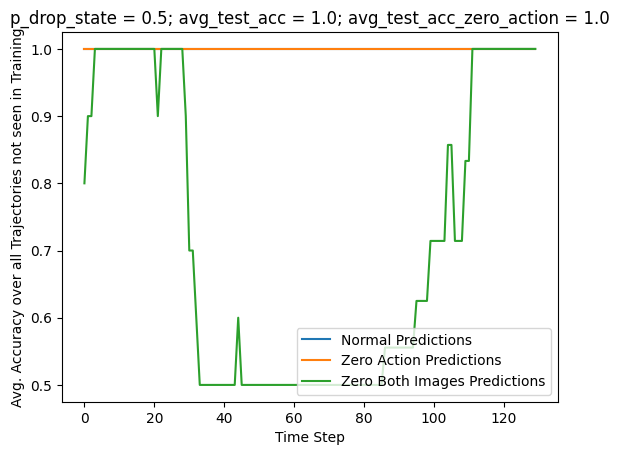

In [11]:
# line plot of normal_predictions_acc and zero_action_predictions_acc over time
plt.xlabel('Time Step')
plt.ylabel('Avg. Accuracy over all Trajectories not seen in Training')

plt.plot(regular_predictions_acc, label='Normal Predictions')
plt.plot(zero_action_predictions_acc, label='Zero Action Predictions')
plt.plot(zero_image_predictions_acc, label='Zero Both Images Predictions')
# plt.plot(zero_eye_in_hand_predictions_acc, label='Zero Wrist Image Predictions')
# plt.plot(zero_agentview_image_predictions_acc, label='Zero Agentview Image Predictions')
plt.title(f"p_drop_state = {p_drop_state}; avg_test_acc = {avg_test_acc}; avg_test_acc_zero_action = {avg_test_acc_zero_action}")
plt.legend(loc='lower right')
plt.show()

# Saving Stuff

In [12]:
import pickle
import json
from pathlib import Path

def save_classifier(network, save_dir, hparams):
    """Save everything needed to restore the classifier."""
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    
    # Save parameters
    with open(save_dir / 'params.pkl', 'wb') as f:
        pickle.dump(network.params, f)
    
    # Save hyperparameters
    with open(save_dir / 'hparams.json', 'w') as f:
        json.dump(hparams, f, indent=2)
    
    print(f"Saved classifier to {save_dir}")


def load_classifier(save_dir):
    """Load classifier from saved directory."""
    save_dir = Path(save_dir)
    
    # Load hyperparameters
    with open(save_dir / 'hparams.json', 'r') as f:
        hparams = json.load(f)
    
    # Load parameters
    with open(save_dir / 'params.pkl', 'rb') as f:
        params = pickle.load(f)
    
    # Recreate model definition
    classifier_def = TransClassifier_BERT(
        vision_encoder=encoder_modules[hparams['encoder']](),
        embed_dim=hparams['embed_dim'],
        layer_norm=hparams['layer_norm'],
        p_drop_state=hparams['p_drop_state'],
    )
    
    networks = {'classifier': classifier_def}
    network_def = ModuleDict(networks)
    network_tx = optax.adam(learning_rate=hparams['lr'])
    network = TrainState.create(network_def, params, tx=network_tx)
    
    return network, hparams

In [13]:
print(f"env_name: {env_name}")


env_name: libero_spatial-pick_up_the_black_bowl_on_the_cookie_box_and_place_it_on_the_plate|libero_spatial-pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate


In [14]:
# Save
hparams = {
    'batch_size': batch_size,
    'horizon_length': horizon_length,
    'discount': discount,
    'encoder': encoder,
    'embed_dim': embed_dim,
    'layer_norm': layer_norm,
    'lr': lr,
    'p_drop_state': p_drop_state,
}
scene_name = 'libero_spatial'
save_classifier(network, f'../checkpoints/libero_bert_classifier_6task_{scene_name}_p_drop_state_0.5_2_epoch', hparams)
# Load
network, hparams = load_classifier(f'../checkpoints/libero_bert_classifier_6task_{scene_name}_p_drop_state_0.5_2_epoch')

Saved classifier to ../checkpoints/libero_bert_classifier_6task_libero_spatial_p_drop_state_0.5_2_epoch


# Evaluation

In [ ]:
import pickle
import json
from pathlib import Path
import time
from agents.acbcflowactor import ACBCFlowActorAgent, get_config as get_actor_config

ACTOR_SEED = 0
class LoggingHelper:
    def __init__(self, wandb_logger):
        self.wandb_logger = wandb_logger
        self.first_time = time.time()
        self.last_time = time.time()

    def log(self, data, prefix, step):
        self.wandb_logger.log({f'{prefix}/{k}': v for k, v in data.items()}, step=step)

def load_classifier(save_dir):
    """Load classifier from saved directory."""
    save_dir = Path(save_dir)
    
    # Load hyperparameters
    with open(save_dir / 'hparams.json', 'r') as f:
        hparams = json.load(f)
    
    # Load parameters
    with open(save_dir / 'params.pkl', 'rb') as f:
        params = pickle.load(f)
    
    # Recreate model definition
    classifier_def = TransClassifier_BERT(
        vision_encoder=encoder_modules[hparams['encoder']](),
        embed_dim=hparams['embed_dim'],
        layer_norm=hparams['layer_norm'],
        p_drop_state=hparams['p_drop_state'],
    )
    
    networks = {'classifier': classifier_def}
    network_def = ModuleDict(networks)
    network_tx = optax.adam(learning_rate=hparams['lr'])
    network = TrainState.create(network_def, params, tx=network_tx)
    
    return network, hparams

class ClassifierAgent:
    def __init__(self, classifier_network_restore_path, actor_restore_path, example_batch, horizon_length, actor_encoder, num_samples):
        class_net, class_hparams = load_classifier(classifier_network_restore_path)
        self.classifier_network = class_net
        self.actor_network = self.restore_actor_network(actor_restore_path, copy.deepcopy(example_batch), horizon_length, actor_encoder)
        self.config = {"action_dim": example_batch["actions"].shape[-1], "horizon_length": horizon_length, "action_chunking": True, "actor_encoder": actor_encoder, "flow_steps": 10, "num_samples": num_samples}

    def restore_actor_network(self, actor_restore_path, example_batch, horizon_length, actor_encoder):
        ex_observations = example_batch['observations']
        ex_actions = example_batch['actions']

        with open(actor_restore_path, 'rb') as f:
            load_dict = pickle.load(f)
        actor_agent_class = ACBCFlowActorAgent
        actor_config = get_actor_config()
        actor_config['encoder'] = actor_encoder
        actor_config['horizon_length'] = horizon_length
        actor_agent = actor_agent_class.create(
            seed=ACTOR_SEED,
            ex_observations=copy.deepcopy(ex_observations),
            ex_actions=copy.deepcopy(ex_actions),
            config=actor_config,
        )
        loaded_actor_params = load_dict['agent']['network']['params']
        actor_agent_state_dict = flax.serialization.to_state_dict(actor_agent)
        actor_agent_params = actor_agent_state_dict['network']['params']

        for key in actor_agent_params:
            if 'actor' in key:
                print(f"for key {key}, copying actor params from actor_restore_path")
                actor_agent_params[key] = loaded_actor_params[key]
        actor_agent = flax.serialization.from_state_dict(actor_agent, actor_agent_state_dict)
        actor_network = actor_agent.network
        return actor_network
    
    def sample_actions(
        self,
        observations,
        rng=None,
        temperature=1.0,
        print_debug=False,
    ):
        """Sample actions: actor_network generates actions, classifier used for rejection sampling."""

        if self.actor_network is None:
            raise ValueError("Actor network not found")

        full_action_dim = self.config["action_dim"] * (self.config["horizon_length"] if self.config["action_chunking"] else 1)
        k = sorted(observations.keys())[0]
        batch_size = observations[k].shape[0]
        
        # Get language embedding before repeating observations
        lang_embedding = observations.pop('language')  # (batch, 768)
        
        if print_debug:
            print(f"[DEBUG] batch_size: {batch_size}, num_samples: {self.config['num_samples']}")
            print(f"[DEBUG] lang_embedding shape: {lang_embedding.shape}")
        
        noises = jax.random.normal(
            rng,
            (
                batch_size,
                self.config['num_samples'],
                full_action_dim,
            ),
        )
        observations = jax.tree_util.tree_map(
            lambda x: jnp.repeat(x[:, None, ...], self.config["num_samples"], axis=1),
            observations
        )
        actions = self.compute_flow_actions(observations, noises)  # (batch, num_samples, full_action_dim)
        actions = jnp.clip(actions, -1, 1)

        if print_debug:
            print(f"[DEBUG] actions shape: {actions.shape}")
            print(f"[DEBUG] actions range: [{float(actions.min()):.4f}, {float(actions.max()):.4f}]")

        # Flatten everything for classifier: (batch * num_samples, ...)
        # before feeding into classifier, drop the proprio to be extra safe (classifier was trained without it)
        observations.pop('proprio')
        flat_obs = jax.tree_util.tree_map(
            lambda x: jnp.reshape(x, (-1,) + x.shape[2:]),
            observations
        )
        flat_actions = jnp.reshape(actions, (-1, full_action_dim))
        flat_lang = jnp.repeat(lang_embedding, self.config['num_samples'], axis=0)
        
        if print_debug:
            print(f"[DEBUG] flat_obs shape: {flat_obs[sorted(flat_obs.keys())[0]].shape}")
            print(f"[DEBUG] flat_actions shape: {flat_actions.shape}")
            print(f"[DEBUG] flat_lang shape: {flat_lang.shape}")
        
        # Get classifier logits
        logits = self.classifier_network.select('classifier')(
            flat_obs, flat_actions, flat_lang, train=False
        )  # (batch * num_samples, 1)
        
        # Reshape logits to (batch, num_samples)
        logits = jnp.reshape(logits, (batch_size, self.config['num_samples']))
        
        if print_debug:
            print(f"[DEBUG] logits shape: {logits.shape}")
            print(f"[DEBUG] logits range: [{float(logits.min()):.4f}, {float(logits.max()):.4f}]")
            print(f"[DEBUG] logits mean: {float(logits.mean()):.4f}, std: {float(logits.std()):.4f}")
            print(f"[DEBUG] logits per batch element - min: {logits.min(axis=-1)}, max: {logits.max(axis=-1)}")
        
        # Pick action with highest logit for each batch element
        indices = jnp.argmax(logits, axis=-1)  # (batch,)
        
        # Get the logits of selected actions
        selected_logits = logits[jnp.arange(batch_size), indices]
        
        if print_debug:
            print(f"[DEBUG] selected indices: {indices}")
            print(f"[DEBUG] selected logits: {selected_logits}")
            print(f"[DEBUG] selected logits mean: {float(selected_logits.mean()):.4f}")
        
        # Select best actions
        actions = actions[jnp.arange(batch_size), indices, :]  # (batch, full_action_dim)
        
        if print_debug:
            print(f"[DEBUG] final actions shape: {actions.shape}")
            print(f"[DEBUG] final actions range: [{float(actions.min()):.4f}, {float(actions.max()):.4f}]")
        
        return actions

    
    def compute_flow_actions(
        self,
        observations,
        noises,
    ):
        """Compute actions from the BC flow model using the Euler method."""
        if self.config['actor_encoder'] is not None:
            observations = self.actor_network.select('actor_flow_encoder')(observations)
        actions = noises
        # Euler method.
        for i in range(self.config['flow_steps']):
            t = jnp.full((*observations.shape[:-1], 1), i / self.config['flow_steps'])
            vels = self.actor_network.select('actor_flow')(observations, actions, t, is_encoded=True)
            actions = actions + vels / self.config['flow_steps']
        actions = jnp.clip(actions, -1, 1)
        return actions

In [ ]:
# classifier_restore_path = '../checkpoints/libero_bert_classifier_2task_living_room_scene1_p_drop_state_0.5'
# actor_restore_path = 'exp/multitask_RL/bcflowactor_unconditional/libero_90-living_room_scene1/bcflowactor_livingroomscene1__alphabet_soup_and_ketchup_NO_LANG_CONDITIONING_50_demos_IMAGE_sd00020260126_113728/params_80000.pkl'

# dataset_actor_trained_with = get_libero_dataset(None, env_name, task_name, language_embedder, augmentation_type, augmentation_reward, keys_to_load + ['proprio'], demo_nums_to_use_per_task=train_demo_nums_to_use, augmentation_dict=None)
# example_batch = dataset_actor_trained_with.sample_sequence(batch_size, sequence_length=horizon_length, discount=discount)
# N = 128
# classifier_agent = ClassifierAgent(classifier_restore_path, actor_restore_path, example_batch, horizon_length, encoder, N)

In [ ]:
# import copy

# # Sample a batch
# example_batch = dataset_actor_trained_with.sample_sequence(
#     batch_size=4,  # small batch for debugging
#     sequence_length=horizon_length, 
#     discount=discount
# )

# # Get observations (make a copy since sample_actions pops 'language')
# example_obs = copy.deepcopy(example_batch['observations'])

# # Set up RNG
# rng = jax.random.PRNGKey(42)

# # Run through the full flow with debug prints
# actions = classifier_agent.sample_actions(
#     example_obs,
#     rng=rng,
#     temperature=1.0,
#     print_debug=True,
# )

# print(f"\n[RESULT] Final actions shape: {actions.shape}")
# print(f"[RESULT] Final actions:\n{actions}")

# # Compare with ground truth actions from batch
# gt_actions = example_batch['actions']
# gt_actions_flat = jnp.reshape(gt_actions, (gt_actions.shape[0], -1))
# print(f"\n[COMPARE] Ground truth actions shape: {gt_actions_flat.shape}")
# print(f"[COMPARE] MSE vs ground truth: {float(jnp.mean((actions - gt_actions_flat) ** 2)):.6f}")

In [ ]:
NUM_EVAL_EPISODES = 50
NUM_VIDEO_EPISODES = 50
NUM_PARALLEL_ENVS = 1
VIDEO_FRAME_SKIP = 3
def eval_agent(agent, eval_env, example_batch, names_to_return, n, logger):
    print(f"Evaluating agent on {len(eval_env)} environments")
    all_eval_info = []
    for j, eval_env_j in tqdm.tqdm(enumerate(eval_env), total=len(eval_env), desc="Evaluating multi-task", position=0,leave=False):
        eval_info, trajs, renders = evaluate(
            agent=agent, 
            env=eval_env_j, 
            action_dim=example_batch["actions"].shape[-1], 
            num_eval_episodes=NUM_EVAL_EPISODES, 
            num_video_episodes=NUM_VIDEO_EPISODES, 
            num_parallel_envs=NUM_PARALLEL_ENVS, 
            video_frame_skip=VIDEO_FRAME_SKIP)
        all_eval_info.append(eval_info)
        if len(renders) > 0:
            # value_and_reward_visualization(trajs, agent, FLAGS.save_dir, log_step)
            eval_info['video'] = get_wandb_video(renders)
        logger.log(eval_info, f"eval_{names_to_return[j]}", step=n)
        # remove video before taking mean
        if 'video' in eval_info:
            del eval_info['video']

    # aggregate eval info via mean, then log under "eval" prefix
    eval_info = {k: np.mean([eval_info[k] for eval_info in all_eval_info]) for k in all_eval_info[0].keys()}
    logger.log(eval_info, "eval", step=n)
    print(f"Eval info: {eval_info}")
    return eval_info

In [ ]:
# from libero.libero.envs import SubprocVectorEnv

# # Try creating just one env without vectorization first
# from envs.libero_utils import make_env as make_libero_env

# single_env, names_to_return = make_libero_env(env_name, task_name, language_embedder, 5)  # adjust params
# print("Single env created successfully")
# single_env = single_env[0]
# obs = single_env.reset()
# print("Single env reset successfully")
# single_env.close()

In [ ]:
# # Cell 4: Try SubprocVectorEnv with minimal setup
# import os
# os.environ['MUJOCO_GL'] = 'egl'  # or 'osmesa' if egl fails

# from libero.libero.envs import SubprocVectorEnv

# def simple_env_fn():
#     # Add debug print inside subprocess
#     import os
#     print(f"[Subprocess PID {os.getpid()}] Creating env...")
#     env = make_libero_env(env_name, task_name, language_embedder, 5)
#     print(f"[Subprocess PID {os.getpid()}] Env created")
#     return env

# # Try with just 1 subprocess first
# vec_env = SubprocVectorEnv([simple_env_fn])
# print("SubprocVectorEnv created")

In [ ]:
import os
os.chdir('/home/yajatyadav/multitask_reinforcement_learning/multitask_RL')

os.environ['CUDA_VISIBLE_DEVICES'] = '7'
os.environ['MUJOCO_GL'] = 'egl'
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags
if 'CUDA_VISIBLE_DEVICES' in os.environ:
    os.environ['EGL_DEVICE_ID'] = os.environ['CUDA_VISIBLE_DEVICES']
    os.environ['MUJOCO_EGL_DEVICE_ID'] = os.environ['CUDA_VISIBLE_DEVICES']


from envs.env_utils import make_env_and_datasets
import wandb
# import multiprocessing
# multiprocessing.set_star
# t_method('spawn', force=True)
env_name = 'libero_90-living_room_scene1'
task_name = 'pick_up_the_alphabet_soup_and_put_it_in_the_basket|pick_up_the_ketchup_and_put_it_in_the_basket'
augmentation_type = 'none'
augmentation_reward = False
language_embedder = 'bert'
keys_to_load = ['agentview_rgb', 'eye_in_hand_rgb', 'language', 'proprio']
horizon_length = 5
discount = 0.99
actor_encoder = 'image_proprio_small'

wandb.init(project="multitask_RL", entity="yajatyadav", group="eval_libero_bert_classifier_2task_living_room_scene1_p_drop_state_0.5", name=f"DEBUG")


_, eval_env, dataset, _, names_to_return = make_env_and_datasets(env_name, task_name, language_embedder, augmentation_type, augmentation_reward, keys_to_load=keys_to_load + ['proprio'], demo_nums_to_use_per_task=[0], augmentation_dict=None, is_notebook=True)
prefixes = ["env", "eval"] + [f"eval_{names_to_return[i]}" for i in range(len(names_to_return))]
prefixes.append("offline_agent")
logger = LoggingHelper(
    wandb_logger=wandb,
)
classifier_restore_path = '../checkpoints/libero_bert_classifier_2task_living_room_scene1_p_drop_state_0.5'
actor_restore_path = 'exp/multitask_RL/bcflowactor_unconditional/libero_90-living_room_scene1/bcflowactor_livingroomscene1__alphabet_soup_and_ketchup_NO_LANG_CONDITIONING_50_demos_IMAGE_sd00020260126_113728/params_80000.pkl'
example_batch = dataset.sample_sequence(1, sequence_length=horizon_length, discount=discount)

for N in [1, 8, 64, 256]:
    print(f"Evaluating with N = {N}")
    classifier_agent = ClassifierAgent(classifier_restore_path, actor_restore_path, example_batch, horizon_length, actor_encoder, N)
    eval_info = eval_agent(classifier_agent, eval_env, example_batch, names_to_return, n=N, logger=logger)   

In [ ]:
env_name = 'libero_90-living_room_scene1-pick_up_the_alphabet_soup_and_put_it_in_the_basket|libero_90-living_room_scene1-pick_up_the_ketchup_and_put_it_in_the_basket'
task_name = ''
language_embedder = 'bert'
keys_to_load = ['language', 'proprio']
horizon_length = 5
discount = 0.99
actor_encoder = 'image_proprio_small'

augmentation_type = 'none'
augmentation_reward = False

_, eval_env, dataset, _, names_to_return = make_env_and_datasets(env_name, task_name, language_embedder, augmentation_type, augmentation_reward, keys_to_load=keys_to_load, demo_nums_to_use_per_task=[0], augmentation_dict=None, is_notebook=True)
